# Demand forecasting with LSTM

This notebook style script follows the same overall build up as the forecasting 'Assignment 2' in energy analytics, but the target is now hourly electricity demand. 

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
#Set global font sizes
plt.rcParams.update({
    "font.size": 14,            # Base font size
    "axes.titlesize": 16,       # Title size
    "axes.labelsize": 14,       # Axis label size
    "xtick.labelsize": 12,      # X-axis tick labels
    "ytick.labelsize": 12,      # Y-axis tick labels
    "legend.fontsize": 12,      # Legend text
})

### Data processing

In [3]:
def create_sequences(X, y, look_back, look_ahead):
    X_out, y_out = [], []

    X = np.asarray(X)
    y = np.asarray(y).reshape(-1)

    for i in range(look_back, len(X) - look_ahead + 1):
        X_out.append(X[i - look_back:i])
        y_out.append(y[i:i + look_ahead])

    return np.array(X_out), np.array(y_out)

### Data processing

In [4]:
FILE_NAME = "Consumption_two_years.csv"
REGION = "Region Hovedstaden"
CATEGORY2 = "Privat"

file_data = os.path.join(os.getcwd(), FILE_NAME)
df_raw = pd.read_csv(file_data, sep=";")

df_raw["TimeUTC"] = pd.to_datetime(df_raw["TimeUTC"])
df_raw["TimeDK"] = pd.to_datetime(df_raw["TimeDK"])

df_raw["ConsumptionkWh"] = (
    df_raw["ConsumptionkWh"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

df_raw = df_raw[
    (df_raw["RegionName"] == REGION) &
    (df_raw["ConsumerCategory2"].str.lower() == CATEGORY2.lower())
].copy()

df_raw = df_raw.sort_values("TimeUTC").reset_index(drop=True)

df_hourly = (
    df_raw.groupby("TimeUTC", as_index=False)["ConsumptionkWh"]
    .sum()
    .sort_values("TimeUTC")
    .reset_index(drop=True)
)

# Time based input variables
df_hourly["hour"] = df_hourly["TimeUTC"].dt.hour
df_hourly["weekday"] = df_hourly["TimeUTC"].dt.weekday
df_hourly["hour_sin"] = np.sin(2 * np.pi * df_hourly["hour"] / 24)
df_hourly["hour_cos"] = np.cos(2 * np.pi * df_hourly["hour"] / 24)
df_hourly["is_weekend"] = (df_hourly["weekday"] >= 5).astype(int)

# Lag variables based on recent consumption and the same hour in the previous day and week
df_hourly["lag_1"] = df_hourly["ConsumptionkWh"].shift(1)
df_hourly["lag_24"] = df_hourly["ConsumptionkWh"].shift(24)
df_hourly["lag_168"] = df_hourly["ConsumptionkWh"].shift(168)

df_hourly = df_hourly.dropna().reset_index(drop=True)

df_hourly = df_hourly.set_index("TimeUTC").asfreq("h")



print("Data period:")
print(df_hourly.index.min())
print(df_hourly.index.max())

print("\nMissing values:")
print(df_hourly.isna().sum())

print("\nShape:")
print(df_hourly.shape)

df_hourly.head()

Data period:
2024-01-07 23:00:00
2026-03-30 21:00:00

Missing values:
ConsumptionkWh    0
hour              0
weekday           0
hour_sin          0
hour_cos          0
is_weekend        0
lag_1             0
lag_24            0
lag_168           0
dtype: int64

Shape:
(19511, 9)


,ConsumptionkWh,hour,weekday,hour_sin,hour_cos,is_weekend,lag_1,lag_24,lag_168
TimeUTC,,,,,,,,,
2024-01-07 23:00:00,404162.262,23,6,-0.258819,0.965926,1,403293.733,436928.583,305809.198
2024-01-08 00:00:00,406760.450,0,0,0.000000,1.000000,0,404162.262,431417.697,297950.077
2024-01-08 01:00:00,394857.401,1,0,0.258819,0.965926,0,406760.450,423902.403,286149.481
2024-01-08 02:00:00,382076.182,2,0,0.500000,0.866025,0,394857.401,411391.982,268110.603
2024-01-08 03:00:00,358977.139,3,0,0.707107,0.707107,0,382076.182,390252.338,246388.437


### Plot of demand series 

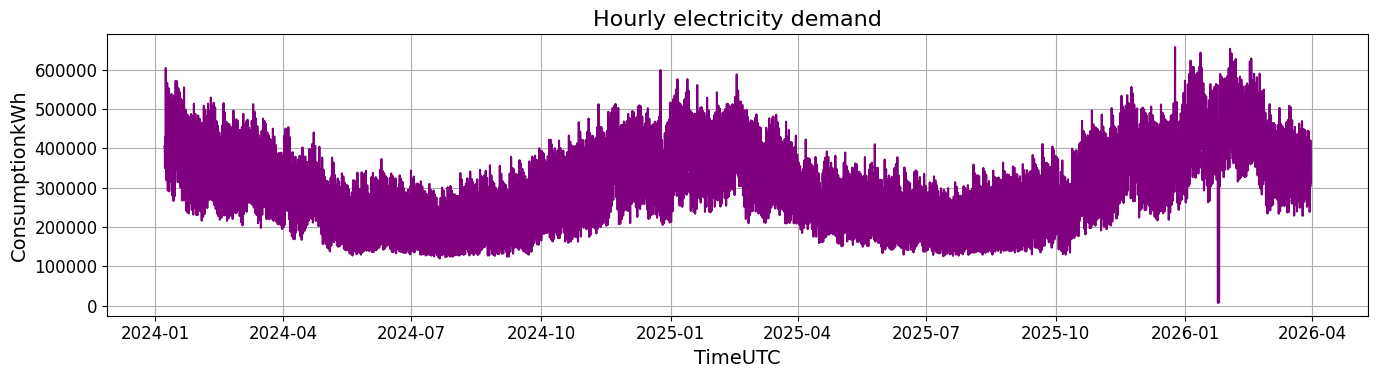

In [5]:
plt.figure(figsize=(14, 4))
plt.plot(df_hourly.index, df_hourly["ConsumptionkWh"], color="purple")
plt.xlabel("TimeUTC")
plt.ylabel("ConsumptionkWh")
plt.title("Hourly electricity demand")
plt.grid()
plt.tight_layout()
plt.show()

### Detect outlier spotted in plot above

In [6]:
threshold = 100000

bad_data = df_hourly[df_hourly["ConsumptionkWh"] < threshold]
print(bad_data.index.min(), bad_data.index.max())

2026-01-23 23:00:00 2026-01-24 22:00:00


In [7]:
#remove outliers
df_hourly = df_hourly[df_hourly["ConsumptionkWh"] > 100000]

In [8]:
df_hourly = df_hourly.asfreq("h")
df_hourly["ConsumptionkWh"] = df_hourly["ConsumptionkWh"].interpolate()

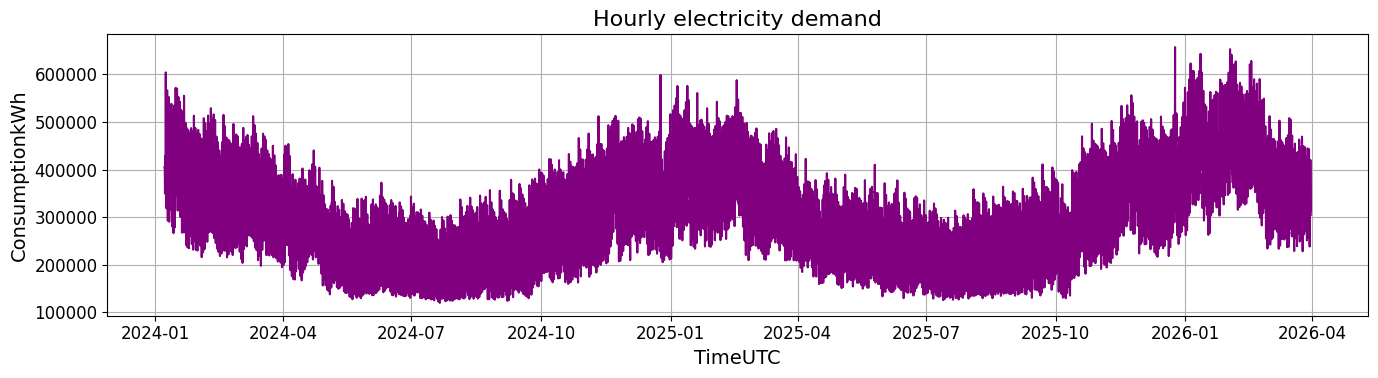

In [9]:
#Plot after outlier removal and interpolation
plt.figure(figsize=(14, 4))
plt.plot(df_hourly.index, df_hourly["ConsumptionkWh"], color="purple")
plt.xlabel("TimeUTC")
plt.ylabel("ConsumptionkWh")
plt.title("Hourly electricity demand")
plt.grid()
plt.tight_layout()
plt.show()

### Tran and test split

In [10]:
look_back = 72
look_ahead = 24 *15 #15 days prediction horizon (due to the delay on consumption data in Energidataservice.dk)

test_start = pd.to_datetime("2025-04-01 00:00:00") #testing on newest month data 
test_end = test_start + pd.Timedelta(hours=look_ahead - 1) 
train_end = test_start - pd.Timedelta(hours=1) #training on all available data up to the test period

df_lstm = df_hourly.loc[:test_end].copy()

trainval_df = df_lstm.loc[:train_end].copy()
test_df = df_lstm.loc[test_start:test_end].copy()

print("Train and test period:")
print(trainval_df.index.min(), "to", trainval_df.index.max())

print("\nTest period:")
print(test_df.index.min(), "to", test_df.index.max())

Train and test period:
2024-01-07 23:00:00 to 2025-03-31 23:00:00

Test period:
2025-04-01 00:00:00 to 2025-04-15 23:00:00


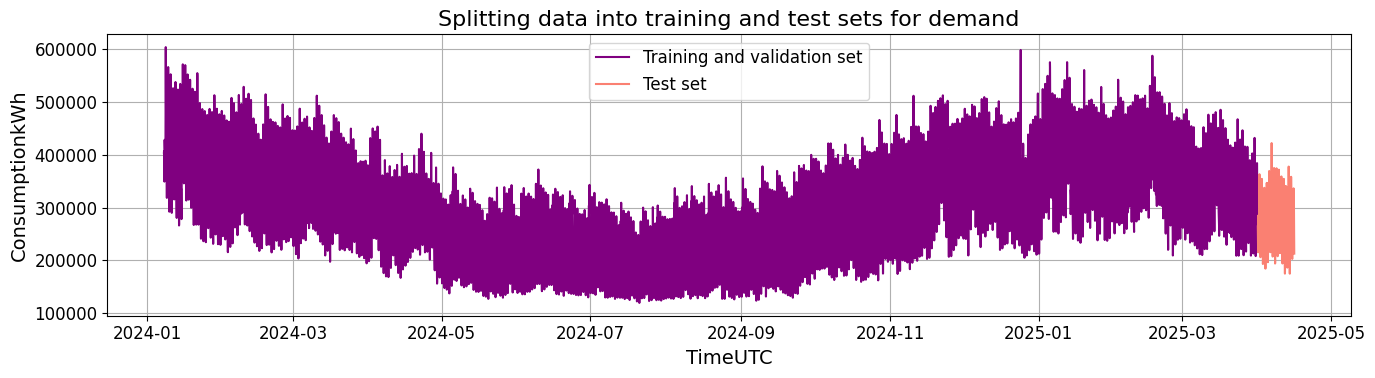

In [11]:
plt.figure(figsize=(14, 4))
plt.plot(trainval_df.index, trainval_df["ConsumptionkWh"], color="purple", label="Training and validation set")
plt.plot(test_df.index, test_df["ConsumptionkWh"], color="salmon", label="Test set")
plt.xlabel("TimeUTC")
plt.ylabel("ConsumptionkWh")
plt.title("Splitting data into training and test sets for demand")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


### Preparing input features and scale data 

In [12]:
feature_cols = [
    "ConsumptionkWh",
    "lag_1",
    "lag_24",
    "lag_168",
    "hour_sin",
    "hour_cos",
    "is_weekend"
]
target_col = ["ConsumptionkWh"]

X_full = df_lstm[feature_cols].values
y_full = df_lstm[target_col].values

test_start_idx = df_lstm.index.get_loc(test_start)
test_end_idx = df_lstm.index.get_loc(test_end) + 1

# Train/validation split
X_trainval = X_full[:test_start_idx]
y_trainval = y_full[:test_start_idx]

# Test set (with look_back history included)
X_test = X_full[test_start_idx - look_back:test_end_idx]
y_test = y_full[test_start_idx - look_back:test_end_idx]

# Save index for correct timestamp alignment
test_input_index = df_lstm.index[test_start_idx - look_back:test_end_idx]

# Scaling
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_trainval_scaled = X_scaler.fit_transform(X_trainval)
y_trainval_scaled = y_scaler.fit_transform(y_trainval)

X_test_scaled = X_scaler.transform(X_test)
y_test_scaled = y_scaler.transform(y_test)

print(X_trainval.shape)
print(X_test.shape)

print(
    f"X_trainval contains {X_trainval.shape[0]} time steps with {X_trainval.shape[1]} features, "
)

print(
    f"used for training and validation. X_test contains {X_test.shape[0]} time steps, which equals ")


print(f"look_back ({look_back}) + look_ahead ({look_ahead}), forming the input window for the final forecast.") 

(10777, 7)
(432, 7)
X_trainval contains 10777 time steps with 7 features, 
used for training and validation. X_test contains 432 time steps, which equals 
look_back (72) + look_ahead (360), forming the input window for the final forecast.


### Splitting training and validation

In [13]:
val_size = int(0.2 * len(X_trainval_scaled))

X_train_scaled = X_trainval_scaled[:-val_size]
y_train_scaled = y_trainval_scaled[:-val_size]

X_val_scaled = X_trainval_scaled[-val_size:]
y_val_scaled = y_trainval_scaled[-val_size:]

print("Training rows:", len(X_train_scaled))
print("Validation rows:", len(X_val_scaled))
print("Test rows:", len(X_test_scaled))


Training rows: 8622
Validation rows: 2155
Test rows: 432


### Sequences for LSTM model 

In [14]:
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, look_back, look_ahead)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, look_back, look_ahead)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, look_back, look_ahead)

print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_val_seq shape:", X_val_seq.shape)
print("y_val_seq shape:", y_val_seq.shape)

print("Each sample in X_train_seq, X_val_seq, and X_test_seq has a shape of (look_back, num_features)," )
print("which is the required input format for LSTM layers. Each corresponding sample ")
print("in y_train_seq, y_val_seq, and y_test_seq has a shape of (look_ahead,), representing the future values to predict.")
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)



X_train_seq shape: (8191, 72, 7)
y_train_seq shape: (8191, 360)
X_val_seq shape: (1724, 72, 7)
y_val_seq shape: (1724, 360)
Each sample in X_train_seq, X_val_seq, and X_test_seq has a shape of (look_back, num_features),
which is the required input format for LSTM layers. Each corresponding sample 
in y_train_seq, y_val_seq, and y_test_seq has a shape of (look_ahead,), representing the future values to predict.
X_test_seq shape: (1, 72, 7)
y_test_seq shape: (1, 360)


### Build and train the LSTM 

In [15]:
model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dense(look_ahead)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

start = time.time()

history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("Training time: {:.2f} seconds".format(time.time() - start))

Epoch 1/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 24s 84ms/step - loss: 0.0145 - mae: 0.0873 - val_loss: 0.0104 - val_mae: 0.0813
Epoch 2/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - loss: 0.0064 - mae: 0.0619 - val_loss: 0.0089 - val_mae: 0.0753
Epoch 3/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 22s 86ms/step - loss: 0.0055 - mae: 0.0574 - val_loss: 0.0080 - val_mae: 0.0705
Epoch 4/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - loss: 0.0050 - mae: 0.0547 - val_loss: 0.0080 - val_mae: 0.0698
Epoch 5/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - loss: 0.0046 - mae: 0.0522 - val_loss: 0.0070 - val_mae: 0.0657
Epoch 6/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 30s 118ms/step - loss: 0.0043 - mae: 0.0507 - val_loss: 0.0070 - val_mae: 0.0654
Epoch 7/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 29s 112ms/step - loss: 0.0042 - mae: 0.0500 - val_loss: 0.0066 - val_mae: 0.0632
Epoch 8/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 28s 110ms/step - loss: 0.0040 - mae: 0.0488 - val_loss: 0.0079 - val_mae: 0.0691
Epoch 9/50
256/256 ━━━━━━━━━━━━━━━━

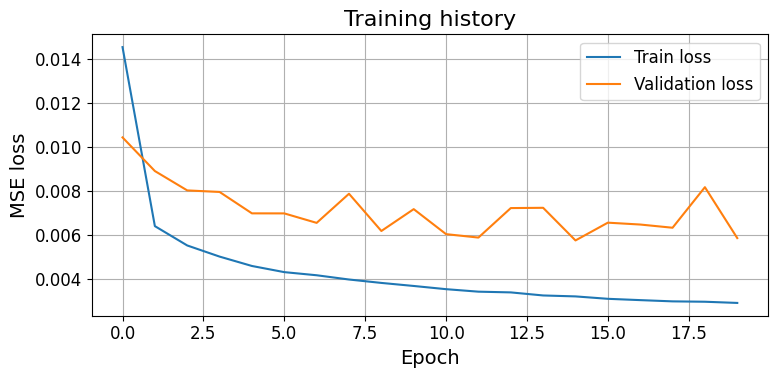

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training history")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Validation forecast

54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step
Validation prediction shape: (1724, 360)
Number of validation sequences: 1724
Number of timestamps: 1724
Selected index: 1247
Forecast start time: 2025-02-25 04:00:00


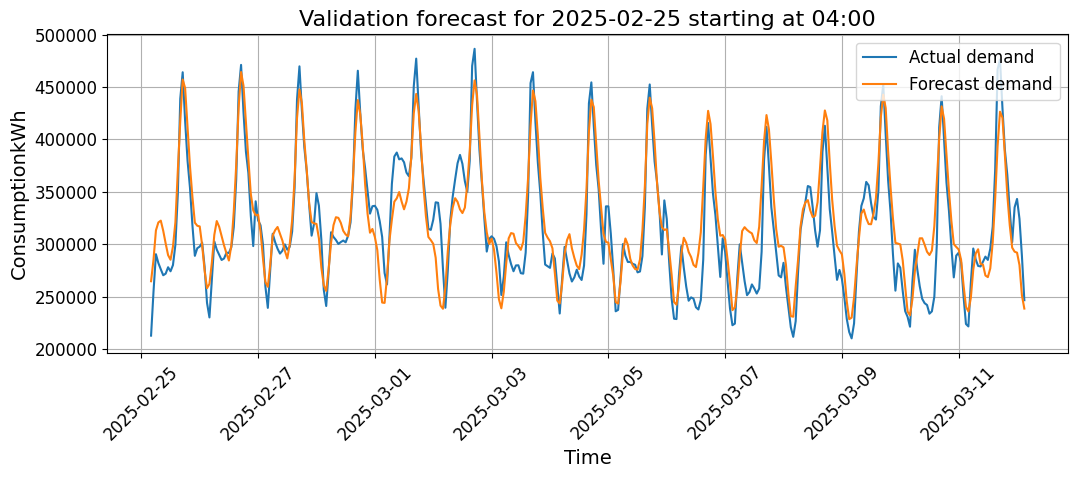

In [17]:
# %% Validation prediction

y_val_pred_scaled = model.predict(X_val_seq)

y_val_pred = y_scaler.inverse_transform(
    y_val_pred_scaled.reshape(-1, 1)
).reshape(y_val_pred_scaled.shape)

y_val_true = y_scaler.inverse_transform(
    y_val_seq.reshape(-1, 1)
).reshape(y_val_seq.shape)

print("Validation prediction shape:", y_val_pred.shape)


# %% Create validation timestamps

val_times = trainval_df.index[-val_size:]

val_forecast_start_times = val_times[
    look_back : len(val_times) - look_ahead + 1
]

print("Number of validation sequences:", len(y_val_true))
print("Number of timestamps:", len(val_forecast_start_times))


# %% Select random 06:00 forecast

six_am_mask = val_forecast_start_times.hour == 4
six_am_indices = np.where(six_am_mask)[0]

if len(six_am_indices) == 0:
    raise ValueError("No validation forecasts start at 06:00")

np.random.seed(42)  # optional, remove for full randomness
example_idx = np.random.choice(six_am_indices)

start_time = val_forecast_start_times[example_idx]

print("Selected index:", example_idx)
print("Forecast start time:", start_time)


# %% Plot 24 hour forecast from 06:00

time_axis = pd.date_range(
    start=start_time,
    periods=look_ahead,
    freq="h"
)

plt.figure(figsize=(11, 5))

plt.plot(time_axis, y_val_true[example_idx], label="Actual demand")
plt.plot(time_axis, y_val_pred[example_idx], label="Forecast demand")

plt.xticks(rotation=45)
plt.xlabel("Time")
plt.ylabel("ConsumptionkWh")
forecast_date = start_time.date()
plt.title(f"Validation forecast for {forecast_date} starting at {start_time.strftime('%H:%M')}")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Final test evaluation 

In [18]:
# %% Final test evaluation and plot

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Predict on test set
y_pred_scaled = model.predict(X_test_seq, verbose=0)

# Inverse transform full 24 hour horizon
y_pred = y_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).reshape(y_pred_scaled.shape)

y_true = y_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
).reshape(y_test_seq.shape)

# Overall 24 hour horizon metrics
overall_rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
overall_mae = mean_absolute_error(y_true.flatten(), y_pred.flatten())
overall_r2 = r2_score(y_true.flatten(), y_pred.flatten())

print(f"24 hour horizon RMSE: {overall_rmse:.3f} kWh")
print(f"24 hour horizon MAE: {overall_mae:.3f} kWh")
print(f"24 hour horizon R²: {overall_r2:.3f}")

# RMSE for each forecast hour
hourly_rmse = []

for h in range(y_true.shape[1]):
    rmse_h = np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h]))
    hourly_rmse.append(rmse_h)
    print(f"Hour {h+1:02d} RMSE: {rmse_h:.3f} kWh")

# RMSE for each 24 hour forecast sequence
daily_rmse = np.array([
    np.sqrt(mean_squared_error(y_true[i], y_pred[i]))
    for i in range(len(y_true))
])

print(f"Average 24 hour forecast RMSE: {daily_rmse.mean():.3f} kWh")
print(f"Minimum 24 hour forecast RMSE: {daily_rmse.min():.3f} kWh")
print(f"Maximum 24 hour forecast RMSE: {daily_rmse.max():.3f} kWh")

# Forecast start timestamps based directly on sequence count
test_forecast_start_times = test_input_index[
    look_back : look_back + len(y_true)
]

# Sanity check
print("Number of test sequences:", len(y_true))
print("Number of forecast start timestamps:", len(test_forecast_start_times))

# Pick one random test forecast that starts at 06:00
six_am_mask = test_forecast_start_times.hour == 6
six_am_indices = np.where(six_am_mask)[0]

if len(six_am_indices) == 0:
    raise ValueError("No test forecasts start at 06:00")

np.random.seed(42)
example_idx = np.random.choice(six_am_indices)

start_time = test_forecast_start_times[example_idx]
time_axis = pd.date_range(start=start_time, periods=look_ahead, freq="h")

# Plot one 24 hour forecast
plt.figure(figsize=(11, 5))
plt.plot(time_axis, y_true[example_idx], label="Actual demand")
plt.plot(time_axis, y_pred[example_idx], label="Forecast demand")

plt.xticks(rotation=45)
plt.xlabel("Time")
plt.ylabel("Consumption [kWh]")
plt.title(
    f"24 hour demand forecast from {start_time.strftime('%Y-%m-%d %H:%M')}"
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

24 hour horizon RMSE: 24428.110 kWh
24 hour horizon MAE: 19474.538 kWh
24 hour horizon R²: 0.744
Hour 01 RMSE: 8071.817 kWh
Hour 02 RMSE: 8012.642 kWh
Hour 03 RMSE: 6143.298 kWh
Hour 04 RMSE: 2789.386 kWh
Hour 05 RMSE: 34546.932 kWh
Hour 06 RMSE: 53605.000 kWh
Hour 07 RMSE: 17663.456 kWh
Hour 08 RMSE: 9040.083 kWh
Hour 09 RMSE: 21895.770 kWh
Hour 10 RMSE: 29106.239 kWh
Hour 11 RMSE: 18761.813 kWh
Hour 12 RMSE: 11167.768 kWh
Hour 13 RMSE: 7161.526 kWh
Hour 14 RMSE: 20642.725 kWh
Hour 15 RMSE: 26752.455 kWh
Hour 16 RMSE: 11074.436 kWh
Hour 17 RMSE: 10985.938 kWh
Hour 18 RMSE: 35257.251 kWh
Hour 19 RMSE: 26193.019 kWh
Hour 20 RMSE: 14174.184 kWh
Hour 21 RMSE: 20298.059 kWh
Hour 22 RMSE: 28402.285 kWh
Hour 23 RMSE: 22864.189 kWh
Hour 24 RMSE: 17236.842 kWh
Hour 25 RMSE: 3385.248 kWh
Hour 26 RMSE: 23973.575 kWh
Hour 27 RMSE: 22817.638 kWh
Hour 28 RMSE: 6793.492 kWh
Hour 29 RMSE: 34546.273 kWh
Hour 30 RMSE: 46096.135 kWh
Hour 31 RMSE: 9303.682 kWh
Hour 32 RMSE: 15254.405 kWh
Hour 33 RMSE: 19

ValueError: No test forecasts start at 06:00

In [19]:
daily_rmse = []

for day in range(15):
    start = day * 24
    end = (day + 1) * 24

    rmse_day = np.sqrt(mean_squared_error(
        y_val_true[:, start:end].flatten(),
        y_val_pred[:, start:end].flatten()
    ))

    daily_rmse.append(rmse_day)

for i, rmse in enumerate(daily_rmse, start=1):
    print(f"Day {i:02d} RMSE: {rmse:.2f} kWh")

Day 01 RMSE: 29859.88 kWh
Day 02 RMSE: 32537.27 kWh
Day 03 RMSE: 34683.54 kWh
Day 04 RMSE: 36606.11 kWh
Day 05 RMSE: 36222.11 kWh
Day 06 RMSE: 37765.52 kWh
Day 07 RMSE: 37465.20 kWh
Day 08 RMSE: 37539.61 kWh
Day 09 RMSE: 37616.90 kWh
Day 10 RMSE: 38676.96 kWh
Day 11 RMSE: 38756.49 kWh
Day 12 RMSE: 38185.56 kWh
Day 13 RMSE: 38479.90 kWh
Day 14 RMSE: 37944.91 kWh
Day 15 RMSE: 38713.26 kWh


In [20]:
print("test_df length:", len(test_df))
print("look_back:", look_back)
print("look_ahead:", look_ahead)

expected_sequences = len(test_df) - look_back - look_ahead + 1
print("Expected sequences from test_df:", expected_sequences)

print("Actual X_test_seq:", len(X_test_seq))
print("Actual y_test_seq:", len(y_test_seq))

test_df length: 360
look_back: 72
look_ahead: 360
Expected sequences from test_df: -71
Actual X_test_seq: 1
Actual y_test_seq: 1


### Saving output for App 

In [21]:
import os
import pickle

save_dir = os.getcwd()

model_path = os.path.join(save_dir, "lstm_model.keras")
scaler_x_path = os.path.join(save_dir, "scaler_X.pkl")
scaler_y_path = os.path.join(save_dir, "scaler_y.pkl")
feature_cols_path = os.path.join(save_dir, "feature_cols.pkl")

with open(feature_cols_path, "wb") as f:
    pickle.dump(feature_cols, f)

print("Saved feature columns to:", feature_cols_path)

model.save(model_path)

with open(scaler_x_path, "wb") as f:
    pickle.dump(X_scaler, f)

with open(scaler_y_path, "wb") as f:
    pickle.dump(y_scaler, f)

print("Saved model to:", model_path)
print("Saved X scaler to:", scaler_x_path)
print("Saved y scaler to:", scaler_y_path)

Saved feature columns to: c:\Users\matil\OneDrive\Skrivebord\Studieportefølje\repos\Bachelor\app\python\forecast\feature_cols.pkl
Saved model to: c:\Users\matil\OneDrive\Skrivebord\Studieportefølje\repos\Bachelor\app\python\forecast\lstm_model.keras
Saved X scaler to: c:\Users\matil\OneDrive\Skrivebord\Studieportefølje\repos\Bachelor\app\python\forecast\scaler_X.pkl
Saved y scaler to: c:\Users\matil\OneDrive\Skrivebord\Studieportefølje\repos\Bachelor\app\python\forecast\scaler_y.pkl


In [22]:
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
print(f"MAPE: {mape:.2f} %")

MAPE: 7.07 %


In [23]:
# Mean demand level (true values)
mean_demand = np.mean(y_true)

# RMSE as percentage
rmse_percent = (overall_rmse / mean_demand) * 100

print(f"Mean demand: {mean_demand:.3f} kWh")
print(f"RMSE as percentage: {rmse_percent:.2f} %")

Mean demand: 270605.592 kWh
RMSE as percentage: 9.03 %
